In [1]:
#reload
import scanpy as sc
adata = sc.read_h5ad("../results/adata_qc_normalized.h5ad")

/home/tanvir-ahmed/scproject2-drosophila-brain/.venv/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


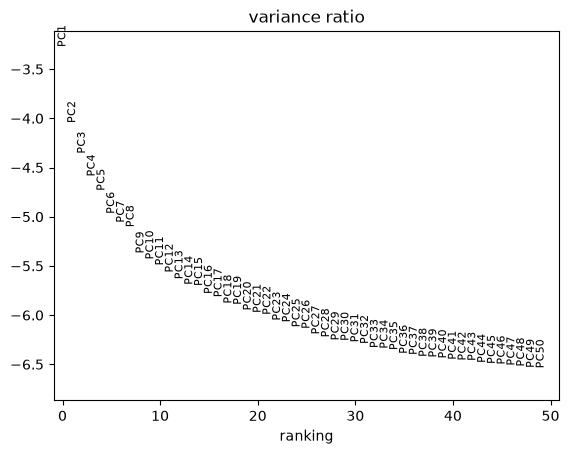

/tmp/ipykernel_5404/1611524862.py:8: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.8, key_added="leiden_res_0.8")


Identified 28 clusters (Target: ~36 per Bainton et al.).


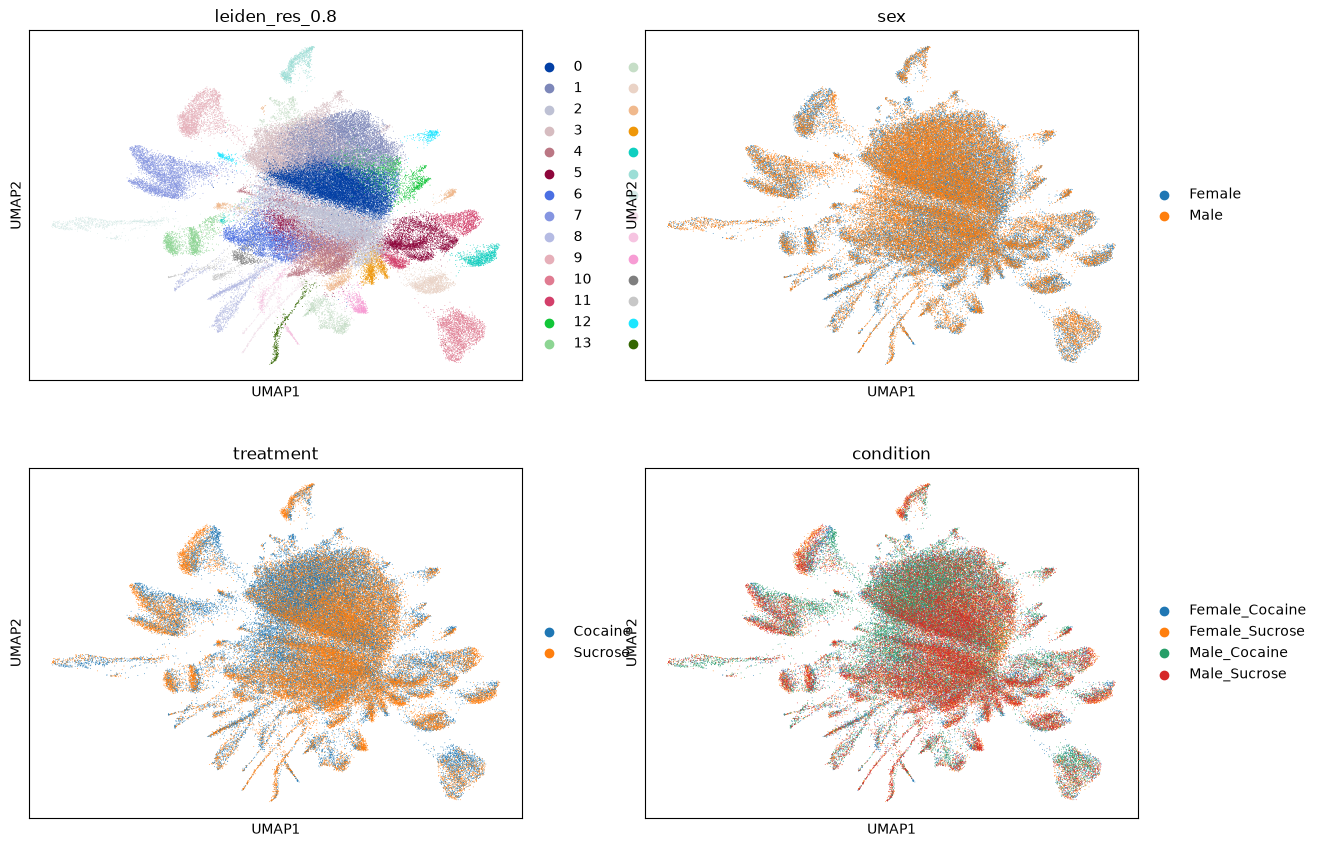

In [2]:
#PCA / neighbors / UMAP / Leiden (target: 36 clusters)

sc.tl.pca(adata, svd_solver="arpack", use_highly_variable=True)
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.8, key_added="leiden_res_0.8")

num_clusters = len(adata.obs["leiden_res_0.8"].unique())
print(f"Identified {num_clusters} clusters (Target: ~36 per Bainton et al.).")

sc.pl.umap(adata, color=["leiden_res_0.8", "sex", "treatment", "condition"], ncols=2)

/home/tanvir-ahmed/scproject2-drosophila-brain/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/tanvir-ahmed/scproject2-drosophila-brain/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/tanvir-ahmed/scproject2-drosophila-brain/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/tanvir-ahmed/scproject2-drosophila-brain/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/tanvir-ahmed/scproject2-drosophila-brain/.venv/lib/python3.11/site-packages/scanpy/tools/_

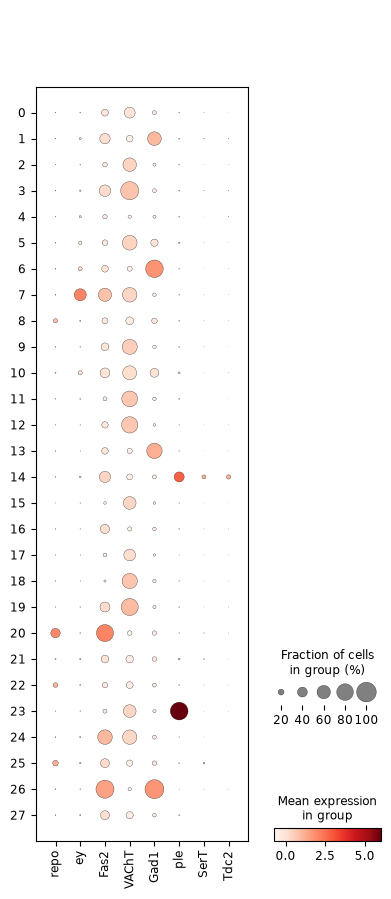

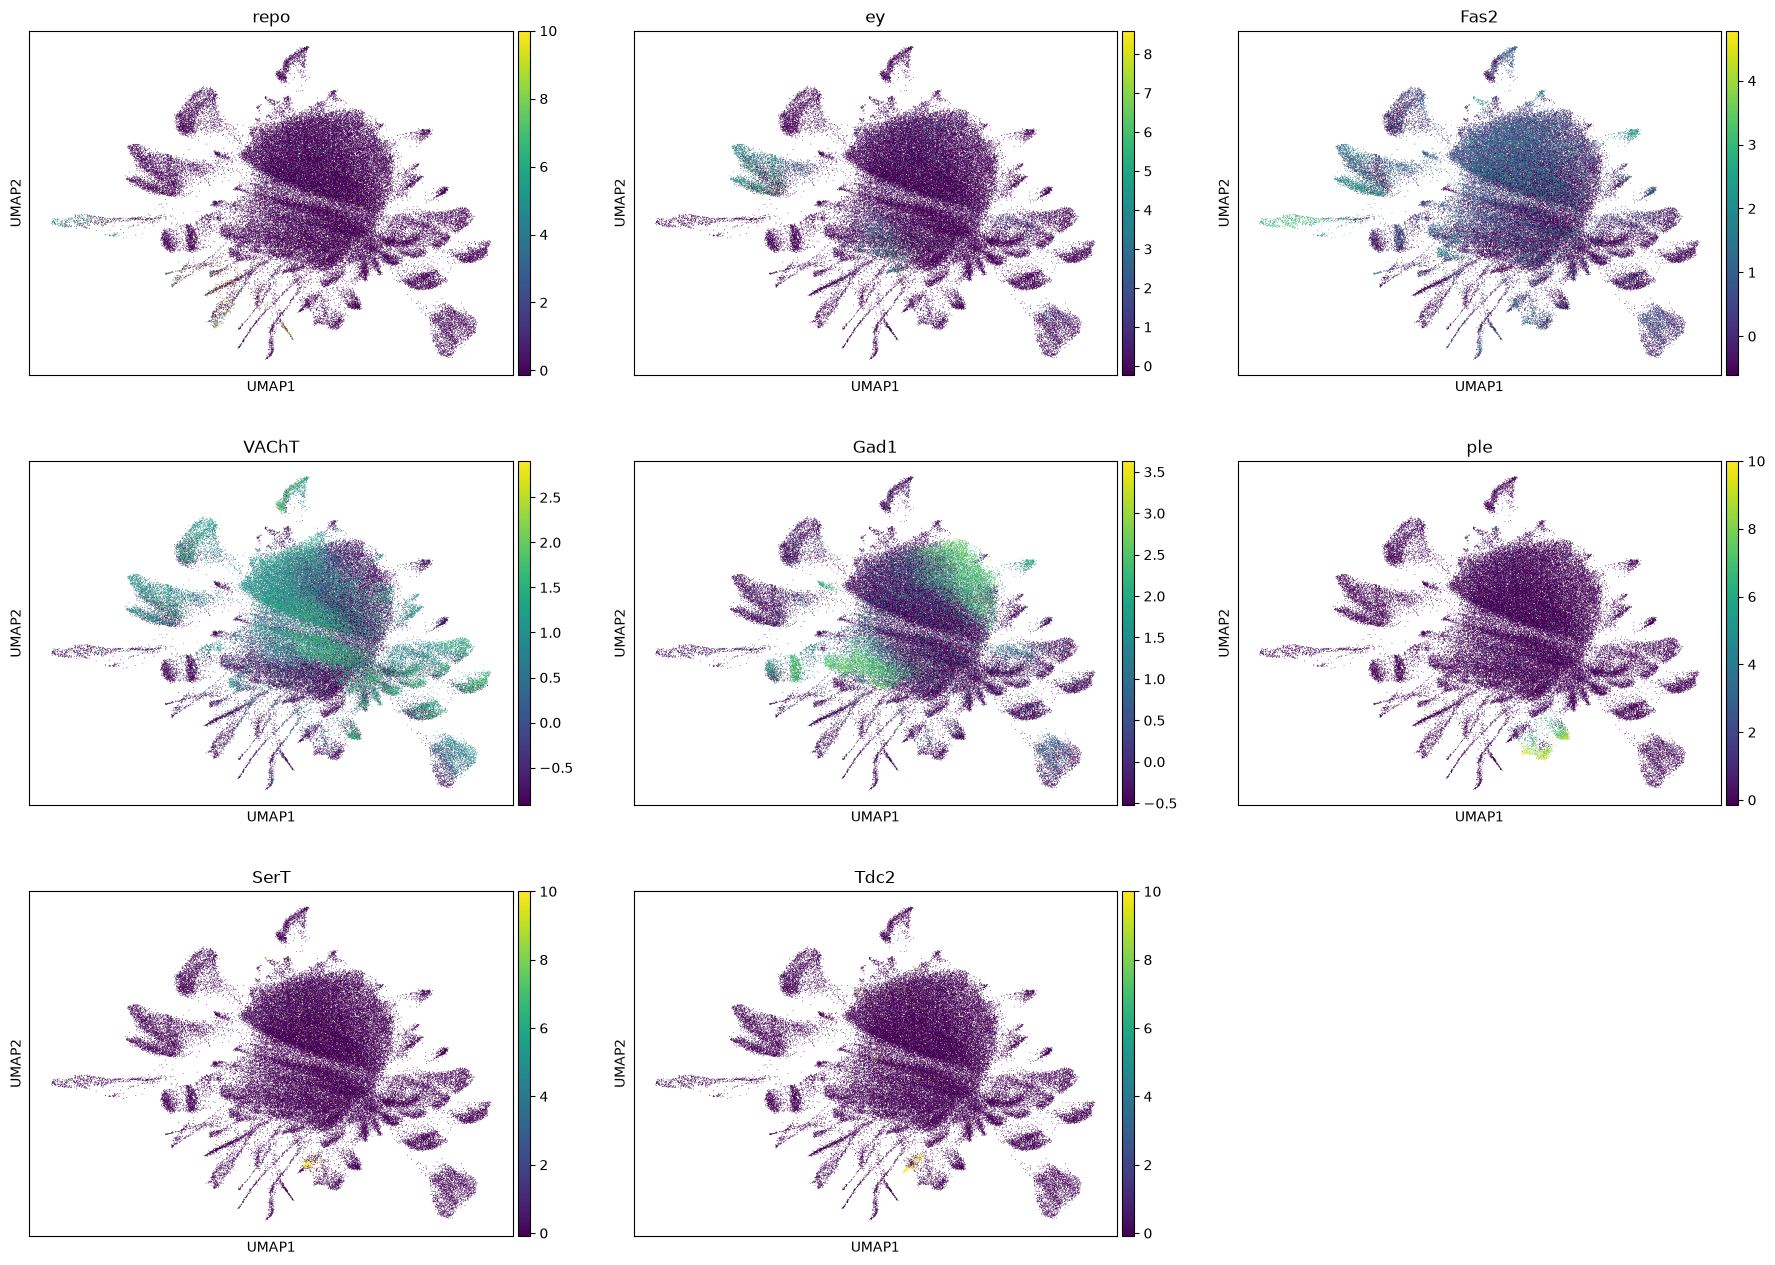

In [3]:
#cell-type annotation with canonical markers

sc.tl.rank_genes_groups(adata, groupby="leiden_res_0.8", method="wilcoxon")

canonical_markers = ["repo", "elav", "ey", "Fas2", "VAChT", "Gad1", "VGlut", "ple", "SerT", "Tdc2"]
available_markers = [g for g in canonical_markers if g in adata.var_names]

sc.pl.dotplot(adata, var_names=available_markers, groupby="leiden_res_0.8")
sc.pl.umap(adata, color=available_markers, ncols=3)

In [4]:
adata.write("../results/adata_clustered.h5ad")


/home/tanvir-ahmed/scproject2-drosophila-brain/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/tanvir-ahmed/scproject2-drosophila-brain/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/tanvir-ahmed/scproject2-drosophila-brain/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/tanvir-ahmed/scproject2-drosophila-brain/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/tanvir-ahmed/scproject2-drosophila-brain/.venv/lib/python3.11/site-packages/scanpy/tools/_

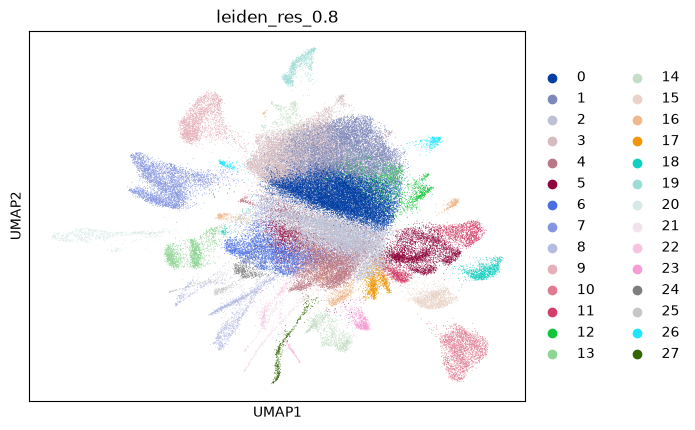

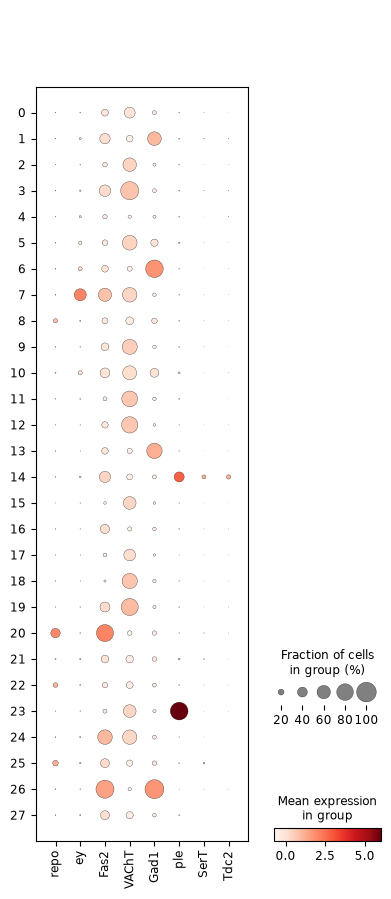

In [5]:
canonical_markers = ["repo", "elav", "ey", "Fas2", "VAChT", "Gad1", "VGlut", "ple", "SerT", "Tdc2"]
available_markers = [g for g in canonical_markers if g in adata.var_names]

sc.tl.rank_genes_groups(adata, groupby="leiden_res_0.8", method="wilcoxon")

sc.settings.figdir = "../results/figures/"
sc.pl.umap(adata, color=["leiden_res_0.8"], save="_fig2_umap_clusters.png")
sc.pl.dotplot(adata, var_names=available_markers, groupby="leiden_res_0.8", save="_fig3_marker_dotplot.png")

adata.write("../results/adata_clustered.h5ad")